### Intsall all dependencies (Ubuntu)

###### Install these from root terminal
```bash
apt-get update > /dev/null
apt install tesseract-ocr
```

In [5]:
!pip install transformers
!pip install torch
!pip install pytesseract

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
E: Could not open lock file /var/lib/apt/lists/lock - open (13: Permission denied)
E: Unable to lock directory /var/lib/apt/lists/
W: Problem unlinking the file /var/cache/apt/pkgcache.bin - RemoveCaches (13: Permission denied)
W: Problem unlinking the file /var/cache/apt/srcpkgcache.bin - RemoveCaches (13: Permission denied)
E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?


### Import all dependencies

In [6]:
from PIL import Image, ImageDraw
from transformers import LayoutLMv3FeatureExtractor, LayoutLMv3ImageProcessor, LayoutLMv3TokenizerFast, LayoutLMv3Processor, LayoutLMv3ForSequenceClassification
import numpy as np

In [30]:
input_image = Image.open('./assets/cash-memo.jpg').convert("RGB")
input_image_width, input_image_height = input_image.size

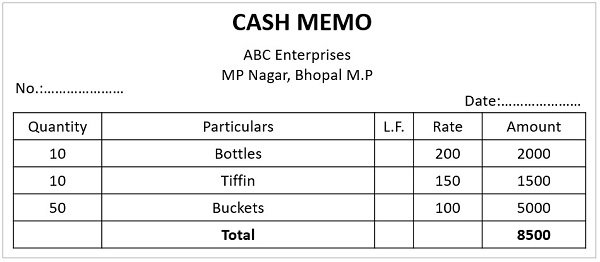

In [3]:
input_image

In [7]:
layoutlm_feature_extractor = LayoutLMv3FeatureExtractor(apply_ocr=True, ocr_lang="eng")
layoutlm_image_processor =  LayoutLMv3ImageProcessor(apply_ocr=True, ocr_lang="eng")
layoutlm_tokenizer = LayoutLMv3TokenizerFast.from_pretrained("microsoft/layoutlmv3-base")
layoutlm_processor = LayoutLMv3Processor(layoutlm_feature_extractor, layoutlm_tokenizer)

In [36]:
layoutlm_processor_encoding = layoutlm_processor(
    input_image,
    max_length = 512,
    padding = "max_length",
    truncation = True,
    return_tensors = "pt"
)

layoutlm_processor_encoding.keys()

dict_keys(['input_ids', 'attention_mask', 'bbox', 'pixel_values'])

In [37]:
print(f"""
input_ids:  { list(layoutlm_processor_encoding["input_ids"].squeeze().shape) }
word boxes: { list(layoutlm_processor_encoding["bbox"].squeeze().shape) }
image data: { list(layoutlm_processor_encoding["pixel_values"].squeeze().shape) }
image size: { input_image.size }
""")


input_ids:  [512]
word boxes: [512, 4]
image data: [3, 224, 224]
image size: (600, 262)



In [17]:
layoutlm_features = layoutlm_feature_extractor(input_image)
layoutlm_image = layoutlm_image_processor(input_image)

In [19]:
print(f"""
--- layoutlm_feature_extractor ---
image size: { layoutlm_features["pixel_values"][0].shape }
word count: { len(layoutlm_features["words"][0]) }
word boxes: { len(layoutlm_features["boxes"][0]) }
""")

print(f"""
--- layoutlm_image_processor ---
image size: { layoutlm_image["pixel_values"][0].shape }
word count: { len(layoutlm_image["words"][0]) }
word boxes: { len(layoutlm_image["boxes"][0]) }
""")


--- layoutlm_feature_extractor ---
image size: (3, 224, 224)
word count: 30
word boxes: 30


--- layoutlm_image_processor ---
image size: (3, 224, 224)
word count: 30
word boxes: 30



In [24]:
input_image_pixel_values = layoutlm_features["pixel_values"][0]
input_image_words = layoutlm_features["words"][0]
input_image_bounding_boxes = layoutlm_features["boxes"][0]

### Converting input_image_pixel_values into a usable image to see what the transformers sees (just for understanding)

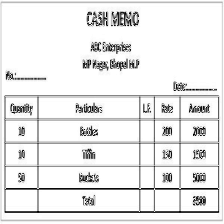

In [25]:

input_image_pixel_values = input_image_pixel_values.transpose(1, 2, 0)
input_image_pixel_values = np.uint8(input_image_pixel_values * 255)

Image.fromarray(input_image_pixel_values, mode="RGB")

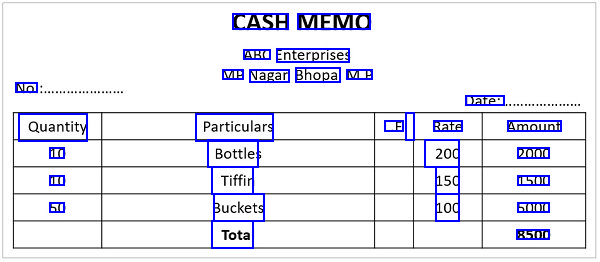

In [33]:
draw_image = input_image.copy()
width_scale = input_image_width / 1000
height_scale = input_image_height / 1000

draw = ImageDraw.Draw(draw_image)

for bbox in input_image_bounding_boxes:
  draw.rectangle(
      [
          bbox[0] * width_scale,
          bbox[1] * height_scale,
          bbox[2] * width_scale,
          bbox[3] * height_scale,
      ],
      outline = "blue",
      width = 2
  )

draw_image

In [38]:
layoutlm_tokenizer_encoding = layoutlm_tokenizer(
    text = input_image_words,
    boxes = input_image_bounding_boxes,
    max_length = 512,
    padding = "max_length",
    truncation = True,
    return_tensors = "pt"
)

In [41]:
input_image_tokens = layoutlm_tokenizer.convert_ids_to_tokens(
    layoutlm_tokenizer_encoding["input_ids"][0],
    skip_special_tokens=True
)

layoutlm_tokenizer.convert_tokens_to_string(input_image_tokens)

' CASH MEMO ABC Enterprises MP Nagar, Bhopal M.P No. Date:.. Quantity Particulars Lp | Rate Amount 10 Bottles 200 2000 10 Tiffin 150 1500 50 Buckets 100 5000 Total 8500'